In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/euskadi/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/euskadi/listings_test.csv")

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal ya llegó a un R²=0.47 razonable, mejor que el de Sevilla y en línea con el resto del proyecto. Con eso en mente, se prueban los mismos cuatro tipos de modelo que en las otras cinco ciudades:

- **Ridge**: versión regularizada de la regresión lineal del baseline. Sirve para ver cuánto más se le puede sacar a un modelo lineal antes de pasar a algo no lineal, especialmente relevante aquí, con el número de condición más alto del proyecto (2.66×10¹⁹).
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest con aleatoriedad extra al elegir los cortes de cada árbol. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`, igual que en las otras ciudades). Admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge). Para Hist Gradient Boosting no se imputa nada, para conservar la información de "sin reviews todavía" que aporta el propio `NaN`.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb`. A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`.

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

71

### 3.2 X e y

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((4536, 71), (1134, 71))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

40

### 3.4 Nulos: sin tratar todavía

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      430
listing_age_days          430
days_since_last_review    430
dtype: int64

## 4. Pipelines

### 4.1 Objetivo: `log1p(price)`

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6.

## 5. Entrenamiento y comparación entre modelos

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(3)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,221.371,83.706,0.372,31.650
Random Forest,214.738,77.208,0.413,28.795
Extra Trees,216.547,77.904,0.403,28.881
Hist Gradient Boosting,208.711,75.359,0.447,28.172


### 5.3 Interpretación

Los cuatro parten ya razonablemente bien encaminados en euros: Ridge (R²=0.372), Random Forest (0.413), Extra Trees (0.403) y Hist Gradient Boosting (0.447, el mejor de los cuatro con hiperparámetros por defecto). A diferencia de Sevilla, donde los cuatro quedaban muy apretados y bajos (0.09-0.13), aquí ya hay separación clara entre Ridge y los árboles, y el nivel de partida es mucho más alto, coherente con el R²=0.47 ya bueno del baseline lineal de `03_model_baseline.ipynb`.

Como en las otras ciudades, esta comparación no decide nada: los tres modelos de árboles se afinan igualmente en la sección 6, no solo el que gane aquí por poco.

## 6. Ajuste de hiperparámetros

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`.

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.707525496349371


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7060997413350233


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 31, 'model__max_iter': 200, 'model__max_depth': 15, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.1}
0.7186036274803346


### 6.4 Resumen

Los tres suben en escala logarítmica: Random Forest a 0.708, Extra Trees a 0.706, Hist Gradient Boosting a **0.719**, el mejor de los tres, aunque por un margen pequeño. Ojo: este número está en la escala de `log1p(price)`, no es directamente comparable con la tabla en euros de la sección 5. La comparación justa en euros se hace en la sección 7.

## 7. Elegir el modelo final

### 7.1 Comparar en euros con los mejores hiperparámetros

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(3)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),213.846,76.585,0.418,28.578
Extra Trees (tuned),215.698,76.616,0.407,28.174
Hist Gradient Boosting (tuned),207.848,74.935,0.452,28.063


### 7.2 Decisión

En euros, el ajuste mejora los tres modelos de forma clara: Random Forest pasa de 0.413 a 0.418, Extra Trees de 0.403 a 0.407, Hist Gradient Boosting de 0.447 a **0.452**. La subida es modesta (a diferencia de la escala logarítmica, donde el salto fue mayor), pero **Hist Gradient Boosting gana con claridad en las cuatro métricas** (RMSE 207.85, MAE 74.94, R² 0.452, MAPE 28.06).

Se elige por eso, además de por los mismos dos motivos ya válidos en las otras ciudades: no necesita imputar `review_scores_rating`/`listing_age_days`/`days_since_last_review`, así que aprovecha la señal de "sin reviews todavía" sin perder información, y mantiene la comparación metodológica con el resto de ciudades, donde también ganó.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               learning_rate=0.05, max_depth=15,
                                               max_iter=200,
                                               random_state=42))])

## 8. Evaluación en test

### 8.1 Evaluar en test, por primera y única vez

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(161.6359793853834),
 'MAE': 70.58643299500076,
 'R2': 0.5926151997087159,
 'MAPE': np.float64(27.138404651640908)}

### 8.2 Train vs. test: ¿hay sobreajuste?

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,178.164312,51.010622,0.599532,17.789172
Test,161.635979,70.586433,0.592615,27.138405


Aquí aparece un patrón poco habitual: el R² es casi idéntico entre train (0.5995) y test (0.5926), nada de sobreajuste, pero el **RMSE de train (178.16€) es más alto que el de test (161.64€)**, justo al revés de lo esperable, mientras que MAE (51.01€ train vs. 70.59€ test) y MAPE (17.79% train vs. 27.14% test) sí muestran el patrón normal (mejor en train).

La explicación está en la propia composición del split: `y_train` tiene una asimetría de 12.13 (frente a 6.17 en test) porque el precio disuasorio de 9.999€ de Sondika, ya detectado en la EDA y otra vez en la FE, cayó en train: su máximo (9.999€) casi cuadruplica el máximo de test (4.222€, la fila de la final de la Europa League). RMSE eleva al cuadrado los errores, así que esa única fila infla el RMSE de train mucho más de lo que MAE/MAPE (que promedian el error absoluto) lo notan. No es un problema de fuga ni de overfitting real: es la tercera vez que ese mismo precio disuasorio deja huella en el proyecto.

## 9. Comparación con el baseline

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 183.65, "MAE": 79.57, "R2": 0.47, "MAPE": 32.40},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 183.65,
  'MAE': 79.57,
  'R2': 0.47,
  'MAPE': 32.4},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(161.6359793853834),
  'MAE': 70.58643299500076,
  'R2': 0.5926151997087159,
  'MAPE': np.float64(27.138404651640908)}}

Mejora en las cuatro métricas: **RMSE de 183.65€ a 161.64€, MAE de 79.57€ a 70.59€, R² de 0.47 a 0.59, MAPE de 32.40% a 27.14%**. El modelo de árboles aporta una mejora real y consistente sobre la regresión lineal del baseline, y el R² final (0.59) queda muy por encima del de Sevilla (0.17): confirma que la relación tamaño-precio en Euskadi es lo bastante fuerte como para que un modelo no lineal la aproveche bien, sin la sensibilidad extrema a un puñado de precios de test que sí lastraba a Sevilla.

## 10. Importancia de variables

### 10.1 Calcular la importancia

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.171845
neighbourhood_price_encoded       0.145748
accommodates                      0.131057
bedrooms                          0.067150
room_type_Entire home/apt         0.055835
distance_to_center_km             0.045179
bathrooms                         0.036254
availability_365                  0.034184
latitude                          0.032963
longitude                         0.014990
review_scores_rating              0.012747
reviews_per_month                 0.009340
calculated_host_listings_count    0.008277
n_nearby_150m                     0.008231
n_amenities                       0.007399
dtype: float64

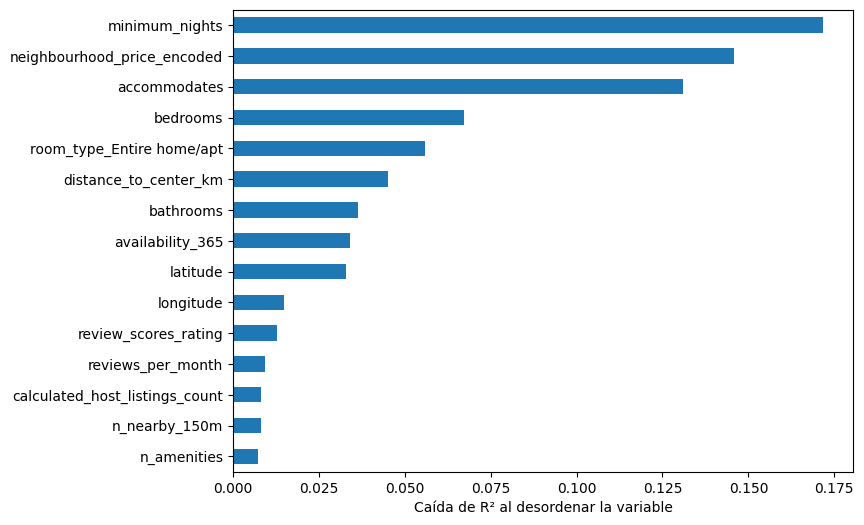

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")
plt.show()

### 10.2 Interpretación

**`minimum_nights` domina** (caída de R² de 0.172), el mismo patrón ya visto en el resto de ciudades: un modelo de árboles aprovecha la relación no lineal "estancias largas más baratas por noche" mucho mejor que una correlación lineal simple. Le sigue muy de cerca `neighbourhood_price_encoded` (0.146): la primera vez en el proyecto que la variable geográfica de precio por zona entra en el podio, coherente con la heterogeneidad de los tres mercados (Bilbao/Donostia/Vitoria) vista en la FE. `accommodates` (0.131) completa el top 3, y `bedrooms` (0.067) y `room_type_Entire home/apt` (0.056) le siguen a más distancia.

`distance_to_center_km` (0.045) entra en el top 6 pese a su correlación global débil en la FE (-0.09): coherente con el hallazgo de que esconde tres patrones opuestos según la capital más cercana: un modelo de árboles puede aprovechar esa heterogeneidad aunque la correlación lineal agregada sea casi nula.

### 10.3 SHAP: cuánto y en qué dirección

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

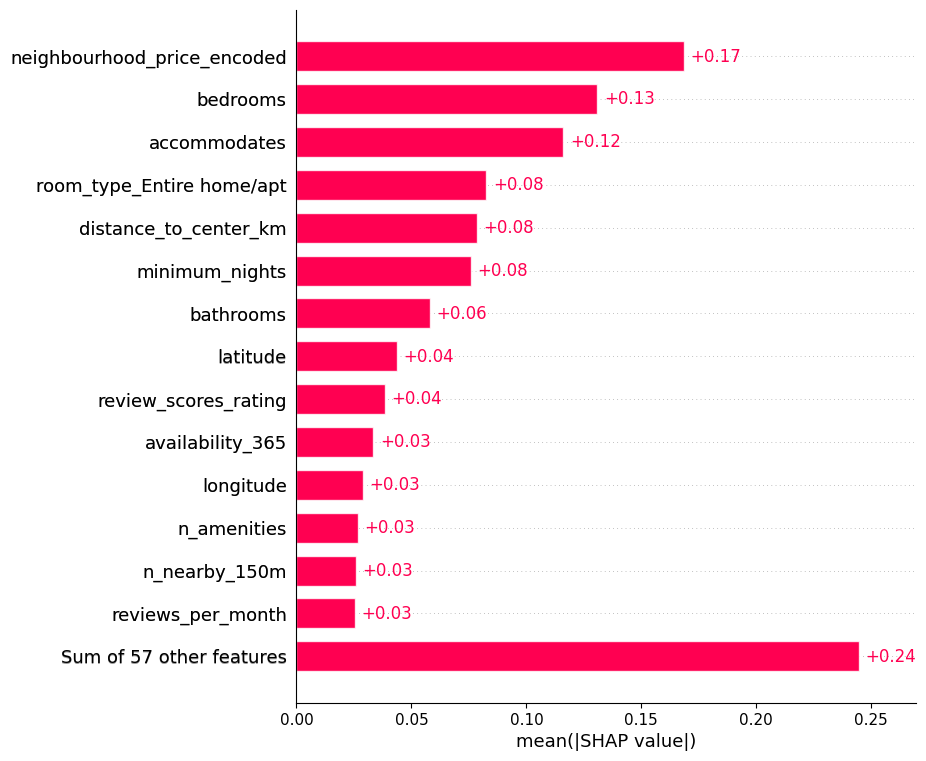

In [22]:
shap.plots.bar(shap_values, max_display=15)

Orden distinto al de la importancia por permutación: SHAP pone a **`neighbourhood_price_encoded`** (0.169) por delante de todo, seguido de `bedrooms` (0.131), `accommodates` (0.116), `room_type_Entire home/apt` (0.083), `distance_to_center_km` (0.079) y solo entonces `minimum_nights` (0.076): el orden inverso casi exacto al de la permutación, que priorizaba `minimum_nights` y dejaba `neighbourhood_price_encoded` en segundo lugar. Es coherente con lo ya visto: ambos métodos coinciden en qué variables importan, pero no en cuál pesa más, porque miden cosas ligeramente distintas (permutación mide caída de R² global al desordenar, SHAP mide la magnitud media del efecto anuncio a anuncio).

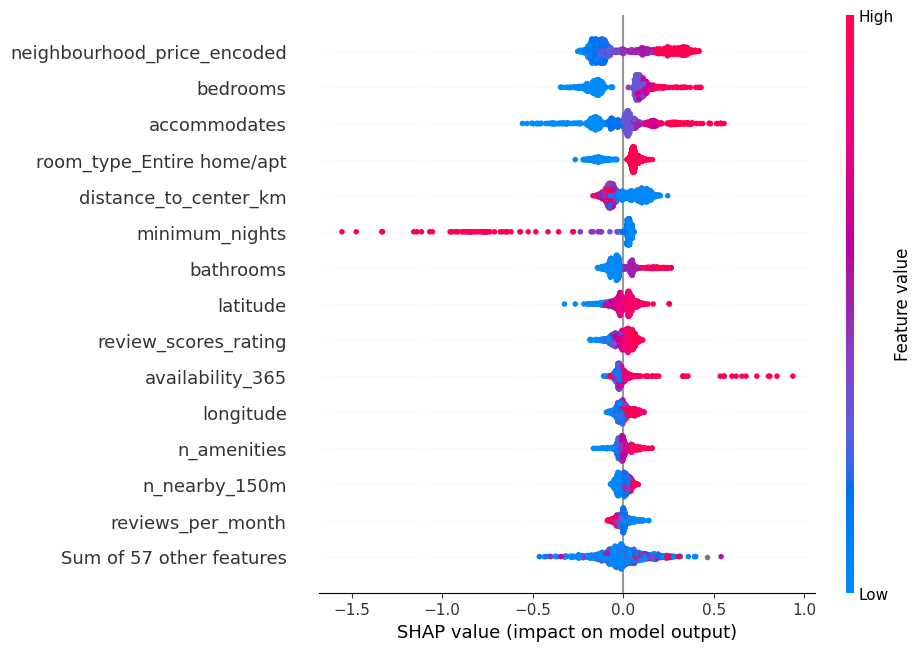

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

Se calcula la correlación entre el valor real de cada variable y su valor SHAP, para confirmar el sentido (positivo/negativo) del efecto de forma numérica, no solo visual.

In [24]:
sv = pd.DataFrame(shap_values.values, columns=X_test.columns, index=X_test.index)
mean_abs_shap = sv.abs().mean().sort_values(ascending=False)

top_feats = mean_abs_shap.head(10).index
direction_feats = {f: X_test[f].corr(sv[f]) for f in top_feats}
pd.Series(direction_feats).sort_values()

minimum_nights                -0.960707
distance_to_center_km         -0.719853
availability_365               0.368326
latitude                       0.760366
review_scores_rating           0.771131
bathrooms                      0.818471
bedrooms                       0.862641
accommodates                   0.918846
neighbourhood_price_encoded    0.963715
room_type_Entire home/apt      0.964075
dtype: float64

Todas las direcciones son las esperadas. `minimum_nights` (-0.96) es, con diferencia, la más negativa: valores altos empujan el precio hacia abajo con fuerza, el patrón de "estancia larga más barata por noche" ya conocido. `distance_to_center_km` también negativa (-0.72): más lejos de la capital de provincia más cercana, precio más bajo: coherente con Donostia (el único de los tres mercados con un patrón centro-periferia claro en la FE, -0.24). Bilbao era plano (0.02) y Vitoria-Gasteiz incluso se invertía (+0.25), pero el efecto agregado del modelo, que combina la distancia con muchas otras variables a la vez, termina dominado por el patrón más fuerte de los tres. Las variables de tamaño empujan hacia arriba con fuerza y consistencia (`accommodates` 0.92, `bedrooms` 0.86, `bathrooms` 0.82), igual que `neighbourhood_price_encoded` (0.96) y `room_type_Entire home/apt` (0.96). `latitude` (0.76) es un resultado propio de Euskadi: más al norte (costa de Vizcaya/Guipúzcoa) es sistemáticamente más caro que más al sur (interior de Álava), reflejo directo del ranking por provincia visto en la EDA. `availability_365` (0.37) es la más débil de las diez, con más dispersión en su efecto.

### 10.4 Un ejemplo concreto

Precio real: 205.00€, predicho: 213.07€


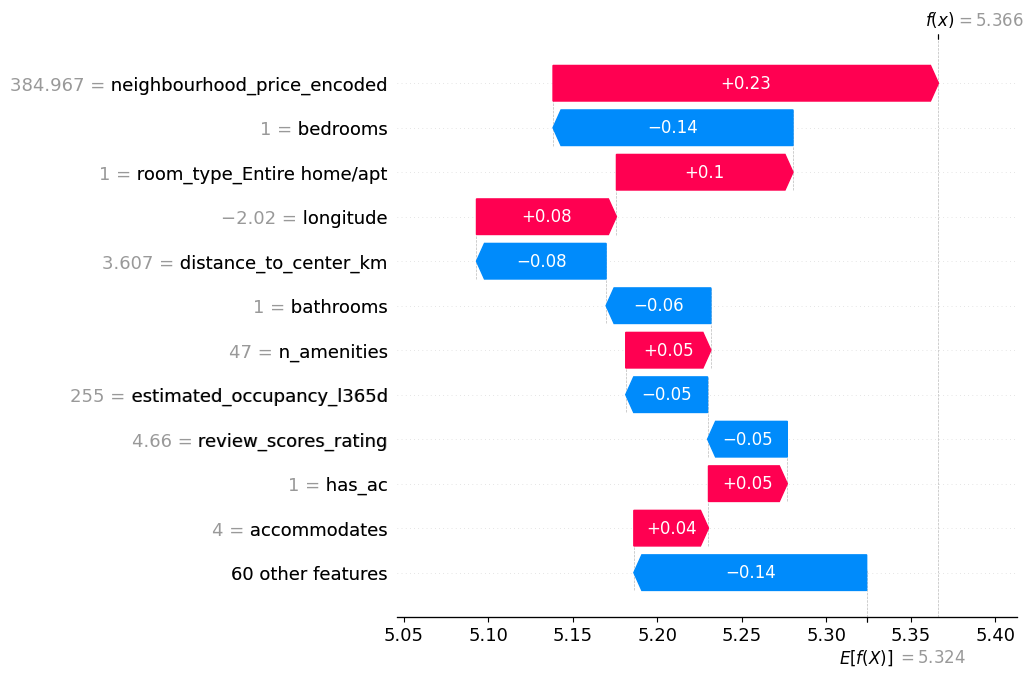

In [25]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`) equivale a unos 204.17€. Para este anuncio en concreto (piso entero para 4 personas, 1 dormitorio, 1 baño, `minimum_nights=1`, disponible 324 días al año, en una zona algo por encima de la media de precio (`neighbourhood_price_encoded=384.97€` frente a una media global de ~262€) y a 3.6km de la capital de provincia más cercana): `neighbourhood_price_encoded` empuja el precio hacia arriba con más fuerza que ninguna otra variable, `room_type_Entire home/apt=1` y la longitud también lo empujan al alza, mientras que `bedrooms=1` (por debajo de lo típico para 4 personas) y `bathrooms=1` lo empujan a la baja, hasta llegar a la predicción final de 213.07€ (el precio real era 205€, un acierto razonable). El mismo tipo de desglose que en las otras ciudades: "tu precio sube sobre todo por estar en una zona cara, pero baja un poco por tener solo 1 dormitorio y 1 baño para 4 personas".

## 11. Guardar el modelo

### 11.1 El modelo

In [26]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/euskadi/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/euskadi/price_model.pkl']

### 11.2 Metadatos

In [27]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 183.65, "MAE": 79.57, "R2": 0.47, "MAPE": 32.40},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/euskadi/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-09',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Guipúzcoa',
  'district_Vizcaya',
  'district_Á

`R2_log` (0.774) es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena, más alto que el R² en euros (0.59), la brecha esperable dado que en euros pesan más los precios extremos (Sondika, la final de la Europa League) que en escala logarítmica quedan comprimidos. Se guarda como métrica adicional para que la app pueda mostrar una cifra de "cuánto explica el modelo" comparable entre ciudades.

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto. Ya con valores por defecto había separación clara entre modelos (R² 0.37-0.45 en euros), con Hist Gradient Boosting por delante.
2. Se afinaron los tres modelos de árboles. En escala logarítmica la mejora fue moderada (hasta R²≈0.72). En euros, subieron los tres de forma consistente aunque modesta (R² 0.41-0.45). Hist Gradient Boosting ganó con claridad en las cuatro métricas.
3. El modelo final se evaluó en test una única vez.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 183.65€ | 79.57€ | 0.47 | 32.40% |
| **Hist Gradient Boosting (final)** | **161.64€** | **70.59€** | **0.59** | **27.14%** |

Mejora real sobre el baseline en las cuatro métricas. Comparado contra train (sección 8.2): R² prácticamente idéntico (0.60 train vs. 0.59 test, sin sobreajuste relevante), pero con una curiosidad: el RMSE de train (178.16€) es más alto que el de test (161.64€), justo al revés de lo habitual, porque el precio disuasorio de 9.999€ de Sondika cayó del lado de train y domina esa métrica en concreto.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en que **`minimum_nights`, `neighbourhood_price_encoded` y el tamaño (`accommodates`/`bedrooms`) dominan**, pero invierten el orden entre sí: la permutación prioriza `minimum_nights` (0.172) sobre `neighbourhood_price_encoded` (0.146), SHAP hace justo lo contrario (0.169 vs. 0.076). Es la primera ciudad del proyecto donde la variable de precio por zona entra en el podio de ambos métodos con tanta fuerza, reflejo directo de la heterogeneidad geográfica de tres mercados (Bilbao/Donostia/Vitoria) documentada en la FE. Las direcciones SHAP confirman todo lo esperado: tamaño y zona cara empujan el precio al alza, estancias mínimas largas y la distancia a la capital más cercana lo empujan a la baja, y `latitude` aporta un efecto propio de Euskadi (norte costero más caro que sur interior) que no tiene equivalente en ninguna otra ciudad del proyecto.

### Qué queda pendiente

- El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/euskadi/price_model.pkl` y `models/euskadi/model_metadata.json` ya guardados aquí.
- Dado que Euskadi tiene 3 mercados geográficos heterogéneos según la capital más cercana (sección 8.1 de la FE), sería especialmente relevante que `05_model_evaluation.ipynb` revise el error por separado en la órbita de Bilbao, Donostia y Vitoria-Gasteiz, no solo de forma agregada.